# Restaurant Data Pipeline
This notebooks prepares data for the op-weg app

In [1]:
import os
import time
import json

import polyline
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import contextily as ctx
from dotenv import load_dotenv
from shapely.geometry import Point

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_PLACES_API_KEY")
RAW_DATA_PATH = "../data/raw/google_places.json"

/Users/stijnvanbalen/opt/anaconda3/lib/python3.7/site-packages/OpenSSL/SSL.py:15: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  from cryptography import x509


## Geoboxing
We define 5 boxes along the route and plot them to check if this makes sense

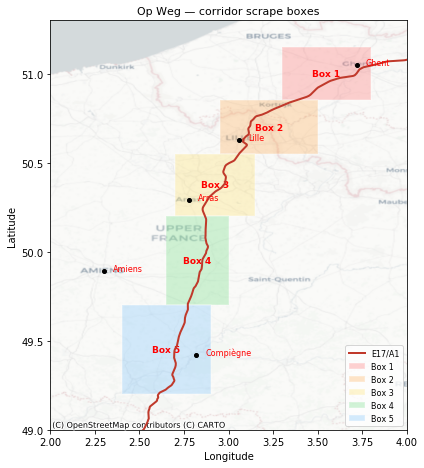

In [10]:

# First we stack 5 boxes 
# Along E17/A1
# Each box: (south, west, north, east)
CORRIDOR_BOXES = [
    (50.85, 3.30, 51.15, 3.80),  # Ghent
    (50.55, 2.95, 50.85, 3.50),  # Kortrijk / Lille
    (50.20, 2.70, 50.55, 3.15),  # Lens / Arras
    (49.70, 2.65, 50.20, 3.00),  # Amiens — extended east
    (49.20, 2.40, 49.70, 2.90),  # Compiègne — trimmed west
]

# We get the a route to plot on the map


def get_route(waypoints):
    """
    Get actual road geometry from OSRM.
    waypoints: list of (lat, lng) tuples
    """
    coords = ";".join([f"{lng},{lat}" for lat, lng in waypoints])
    url = f"http://router.project-osrm.org/route/v1/driving/{coords}"
    params = {"overview": "full", "geometries": "polyline"}
    response = requests.get(url, params=params).json()
    encoded = response["routes"][0]["geometry"]
    # Returns list of (lat, lng) tuples
    return polyline.decode(encoded)

waypoints = [
    (52.38, 4.63),   # Haarlem
    (48.85, 2.35),   # Paris
]

route_coords = get_route(waypoints)


fig, ax = plt.subplots(1, 1, figsize=(6, 10))

ax.set_xlim(2.0, 4.0)
ax.set_ylim(49.0, 51.3)
# Next we map out the boxes
# Plot boxes
colors = ["#ff6b6b", "#ffa94d", "#ffe066", "#69db7c", "#74c0fc"]
for i, (south, west, north, east) in enumerate(CORRIDOR_BOXES):
    rect = patches.Rectangle(
        (west, south), east - west, north - south,
        linewidth=1.5, edgecolor="white",
        facecolor=colors[i], alpha=0.3, label=f"Box {i+1}"
    )
    ax.add_patch(rect)
    ax.text(
        (west + east) / 2, (south + north) / 2,
        f"Box {i+1}", ha="center", va="center",
        fontsize=9, fontweight="bold", color="red"
    )

# Reference cities
cities = {
    "Ghent": (3.72, 51.05),
    "Lille": (3.06, 50.63),
    "Arras": (2.78, 50.29),
    "Amiens": (2.30, 49.89),
    "Compiègne": (2.82, 49.42),
}
for city, (lng, lat) in cities.items():
    ax.plot(lng, lat, "ko", markersize=4, zorder=5)
    ax.text(lng + 0.05, lat, city, fontsize=8, color="red", zorder=5)

# Actual E17/A1 route from OSRM
route_lng = [p[1] for p in route_coords]
route_lat = [p[0] for p in route_coords]
ax.plot(route_lng, route_lat, color="#c0392b", linewidth=2,
        linestyle="-", zorder=4, label="E17/A1")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Op Weg — corridor scrape boxes", fontsize=11)
ax.legend(loc="lower right", fontsize=8)

ctx.add_basemap(ax, crs="EPSG:4326",
                source=ctx.providers.CartoDB.Positron,
                zoom=8)

plt.tight_layout()
plt.savefig("../data/raw/corridor_boxes_map.png", dpi=150)
plt.show()

## Downloading
Getting restaurants from the Google API

In [3]:
def search_box(south, west, north, east):
    """Search Google Places for restaurants in a bounding box."""
    lat = (south + north) / 2
    lng = (west + east) / 2
    radius = 30000  # 30km — covers the box width

    url = "https://maps.googleapis.com/maps/api/place/nearbysearch/json"
    results = []
    params = {
        "location": f"{lat},{lng}",
        "radius": radius,
        "type": "restaurant",
        "key": GOOGLE_API_KEY,
    }

    while True:
        response = requests.get(url, params=params).json()
        results.extend(response.get("results", []))
        next_page = response.get("next_page_token")
        if not next_page:
            break
        time.sleep(2)  # Google requires a short delay between pages
        params = {"pagetoken": next_page, "key": GOOGLE_API_KEY}

    return results

all_candidates = []
for i, box in enumerate(CORRIDOR_BOXES):
    print(f"Scraping box {i+1}/5...")
    results = search_box(*box)
    print(f"  → {len(results)} candidates")
    all_candidates.extend(results)

# Deduplicate on place_id
seen = set()
unique = []
for r in all_candidates:
    if r["place_id"] not in seen:
        seen.add(r["place_id"])
        unique.append(r)

print(f"\nTotal unique candidates: {len(unique)}")

with open(RAW_DATA_PATH, "w") as f:
    json.dump(unique, f, indent=2)

print(f"Saved to {RAW_DATA_PATH}")

Scraping box 1/5...
  → 60 candidates
Scraping box 2/5...
  → 60 candidates
Scraping box 3/5...
  → 60 candidates
Scraping box 4/5...
  → 60 candidates
Scraping box 5/5...
  → 60 candidates

Total unique candidates: 285
Saved to ../data/raw/google_places.json


## Transforming the data to a dataframe

In [4]:
with open(RAW_DATA_PATH, "r") as f:
    raw = json.load(f)

def flatten(place):
    return {
        "place_id":     place.get("place_id"),
        "name":         place.get("name"),
        "address":      place.get("vicinity"),
        "lat":          place["geometry"]["location"]["lat"],
        "lng":          place["geometry"]["location"]["lng"],
        "rating":       place.get("rating"),
        "user_ratings":  place.get("user_ratings_total"),
        "price_level":  place.get("price_level"),
        "open_now":     place.get("opening_hours", {}).get("open_now"),
        "types":        ", ".join(place.get("types", [])),
    }

df = pd.DataFrame([flatten(p) for p in raw])
print(f"{len(df)} candidates")
print(df.head())

285 candidates
                      place_id                     name  \
0  ChIJD3y6ZeFzw0cR6kk1wbpyNgM       Astoria Hotel Gent   
1  ChIJPT_9nPVzw0cR5j37wXDGyCs                Campanile   
2  ChIJ3a6T8EZxw0cRp51VaCPBbwk     Novotel Gent Centrum   
3  ChIJyT5TL0Jxw0cRZMufwEERueA  Monasterium PoortAckere   
4  ChIJM_cyBKRtw0cRIfq85IfKO3k       Auberge Du Pêcheur   

                             address        lat       lng  rating  \
0    Achilles Musschestraat 39, Gent  51.033336  3.716949     4.5   
1                  Akkerhage 1, Gent  51.019509  3.736081     3.1   
2                 Hoogpoort 52, Gent  51.054888  3.724271     4.1   
3              Oude Houtlei 56, Gent  51.052744  3.716730     4.1   
4  Pontstraat 41, Sint-Martens-Latem  51.004372  3.602220     4.3   

   user_ratings  price_level open_now  \
0         613.0          NaN     True   
1         952.0          NaN     None   
2        2147.0          NaN     None   
3         984.0          NaN     True   
4        1

## We filter the dataframe 
On establishment type and on some names indicating chains

In [5]:
# Drop ratings lower than 3.5
df_filtered = df[
    df["rating"] >= 3.5
].copy()

print(f"After filter on rating\t: {len(df_filtered)} candidates")

# Drop anything that is clearly not a sit-down restaurant
exclude_types = ["lodging", "store", "supermarket", "gas_station", 
                 "convenience_store", "cafe", "bakery", "bar"]

df_filtered = df_filtered[
    ~df_filtered["types"].str.contains("|".join(exclude_types), na=False)
]

print(f"After filter on type\t: {len(df_filtered)} candidates")

# Drop restaurants that have chain names in their name
CHAIN_BLOCKLIST = [
    "van der valk", "mcdonald", "quick", "buffalo grill", 
    "courtepaille", "flunch", "hippopotamus", "leon",
    "pizza hut", "domino", "subway", "burger king"
]

def is_chain(name):
    return any(chain in name.lower() for chain in CHAIN_BLOCKLIST)

df_filtered = df_filtered[~df_filtered["name"].apply(is_chain)]

print(f"After filter on chains\t: {len(df_filtered)} candidates")

EXCLUDE_TYPES = ["meal_takeaway", "meal_delivery", "spa"]

df_filtered = df_filtered[
    ~df_filtered["types"].apply(
        lambda t: any(ex in t.split(", ") for ex in EXCLUDE_TYPES)
    )
]

print(f"After filter on type\t: {len(df_filtered)} candidates")

After filter on rating	: 261 candidates
After filter on type	: 99 candidates
After filter on chains	: 93 candidates
After filter on type	: 84 candidates


In [8]:
city_centres = {
    "Ghent":      (3.7174, 51.0543, 1.5),
    "Lille":      (3.0573, 50.6292, 1.5),
    "Compiègne":  (2.8278, 49.4183, 0.5),
}

def in_city_centre(row):
    point = Point(row["lng"], row["lat"])
    for city, (lng, lat, radius_km) in city_centres.items():
        centre = Point(lng, lat)
        if point.distance(centre) * 80 < radius_km:
            return True
    return False

df_filtered = df_filtered[~df_filtered.apply(in_city_centre, axis=1)].copy()
print(f"After city centre filter: {len(df_filtered)}")

After city centre filter: 61


## Plotting the results

/Users/stijnvanbalen/opt/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 127470 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/stijnvanbalen/opt/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 127481 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/stijnvanbalen/opt/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:180: RuntimeWarning: Glyph 127470 missing from current font.
  font.set_text(s, 0, flags=flags)
/Users/stijnvanbalen/opt/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:180: RuntimeWarning: Glyph 127481 missing from current font.
  font.set_text(s, 0, flags=flags)


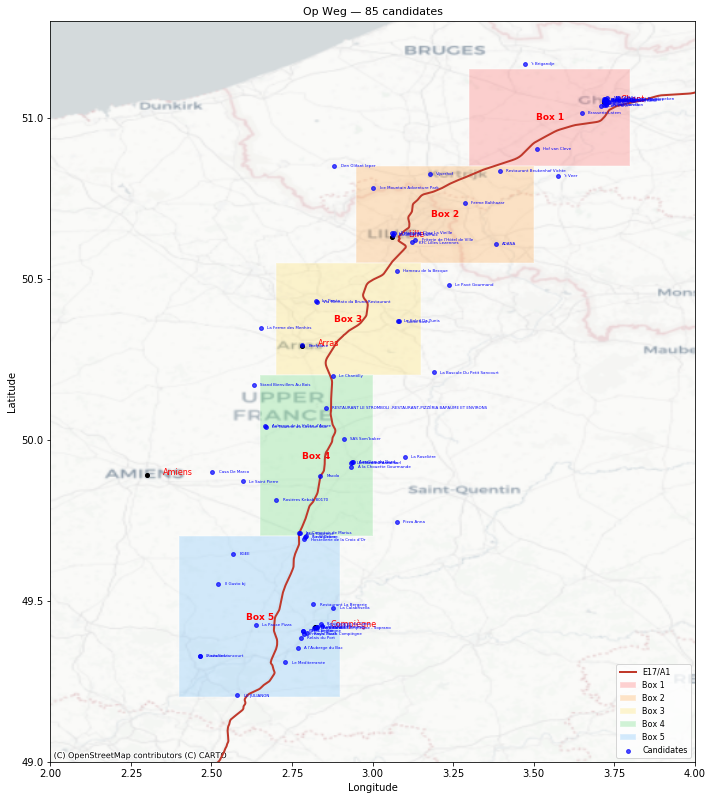

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 16))
ax.set_xlim(2.0, 4.0)
ax.set_ylim(49.0, 51.3)

# Boxes
colors = ["#ff6b6b", "#ffa94d", "#ffe066", "#69db7c", "#74c0fc"]
for i, (south, west, north, east) in enumerate(CORRIDOR_BOXES):
    rect = patches.Rectangle(
        (west, south), east - west, north - south,
        linewidth=1.5, edgecolor="white",
        facecolor=colors[i], alpha=0.3, label=f"Box {i+1}"
    )
    ax.add_patch(rect)
    ax.text(
        (west + east) / 2, (south + north) / 2,
        f"Box {i+1}", ha="center", va="center",
        fontsize=9, fontweight="bold", color="red"
    )

# Steden
cities = {
    "Ghent": (3.72, 51.05),
    "Lille": (3.06, 50.63),
    "Arras": (2.78, 50.29),
    "Amiens": (2.30, 49.89),
    "Compiègne": (2.82, 49.42),
}
for city, (lng, lat) in cities.items():
    ax.plot(lng, lat, "ko", markersize=4, zorder=5)
    ax.text(lng + 0.05, lat, city, fontsize=8, color="red", zorder=5)

# Route
route_lng = [p[1] for p in route_coords]
route_lat = [p[0] for p in route_coords]
ax.plot(route_lng, route_lat, color="#c0392b", linewidth=2,
        linestyle="-", zorder=4, label="E17/A1")

# Restaurants
ax.scatter(
    df_filtered["lng"], df_filtered["lat"],
    s=15, color="blue", alpha=0.7, zorder=6, label="Candidates"
)
for _, row in df_filtered.iterrows():
    ax.text(row["lng"] + 0.02, row["lat"], row["name"],
            fontsize=4, color="blue", va="center", zorder=7)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Op Weg — {len(df_filtered)} candidates", fontsize=11)
ax.legend(loc="lower right", fontsize=8)

ctx.add_basemap(ax, crs="EPSG:4326",
                source=ctx.providers.CartoDB.Positron,
                zoom=8)

plt.tight_layout()
plt.savefig("../data/raw/corridor_boxes_map.png", dpi=150)
plt.show()

In [9]:
os.makedirs("../data/processed", exist_ok=True)

df_filtered["google_maps_url"] = df_filtered.apply(
    lambda row: f"https://www.google.com/maps/search/?api=1&query={row['lat']},{row['lng']}&query_place_id={row['place_id']}",
    axis=1
)

df_filtered.to_excel("../data/processed/candidates.xlsx", index=False)
print(f"Exported {len(df_filtered)} candidates to candidates.xlsx")

Exported 61 candidates to candidates.xlsx


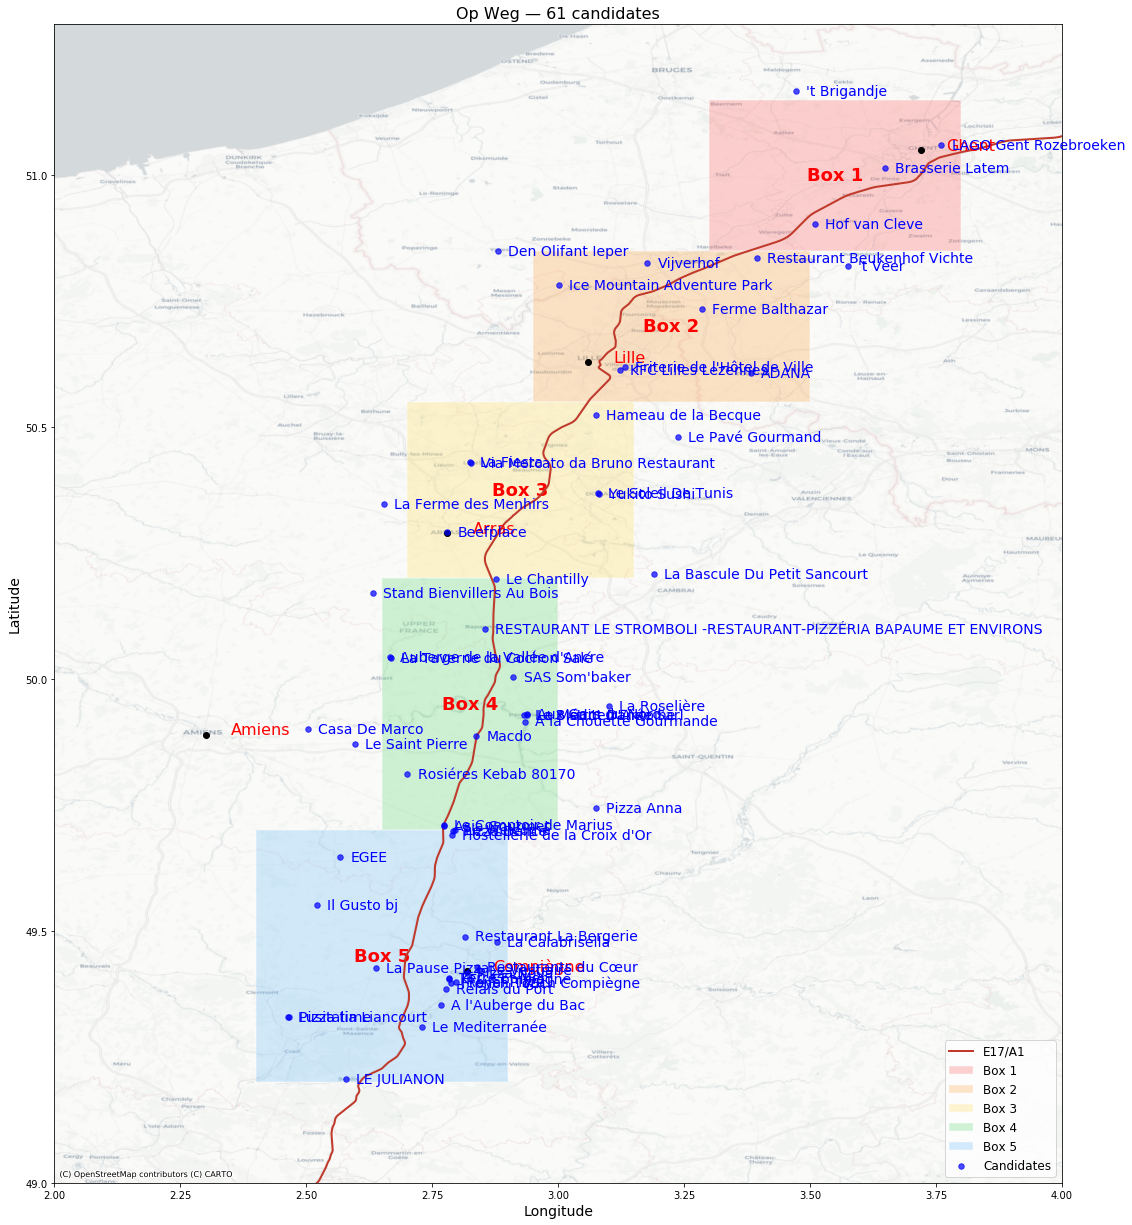

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(16, 24))
ax.set_xlim(2.0, 4.0)
ax.set_ylim(49.0, 51.3)

# Boxes
colors = ["#ff6b6b", "#ffa94d", "#ffe066", "#69db7c", "#74c0fc"]
for i, (south, west, north, east) in enumerate(CORRIDOR_BOXES):
    rect = patches.Rectangle(
        (west, south), east - west, north - south,
        linewidth=1.5, edgecolor="white",
        facecolor=colors[i], alpha=0.3, label=f"Box {i+1}"
    )
    ax.add_patch(rect)
    ax.text(
        (west + east) / 2, (south + north) / 2,
        f"Box {i+1}", ha="center", va="center",
        fontsize=18, fontweight="bold", color="red"
    )

# Steden
cities = {
    "Ghent": (3.72, 51.05),
    "Lille": (3.06, 50.63),
    "Arras": (2.78, 50.29),
    "Amiens": (2.30, 49.89),
    "Compiègne": (2.82, 49.42),
}
for city, (lng, lat) in cities.items():
    ax.plot(lng, lat, "ko", markersize=6, zorder=5)
    ax.text(lng + 0.05, lat, city, fontsize=16, color="red", zorder=5)

# Route
route_coords = get_route(waypoints)
route_lng = [p[1] for p in route_coords]
route_lat = [p[0] for p in route_coords]
ax.plot(route_lng, route_lat, color="#c0392b", linewidth=2,
        linestyle="-", zorder=4, label="E17/A1")

# Restaurants
ax.scatter(
    df_filtered["lng"], df_filtered["lat"],
    s=30, color="blue", alpha=0.7, zorder=6, label="Candidates"
)
for _, row in df_filtered.iterrows():
    ax.text(row["lng"] + 0.02, row["lat"], row["name"],
            fontsize=14, color="blue", va="center", zorder=7)

ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.set_title(f"Op Weg — {len(df_filtered)} candidates", fontsize=16)
ax.legend(loc="lower right", fontsize=12)

ctx.add_basemap(ax, crs="EPSG:4326",
                source=ctx.providers.CartoDB.Positron,
                zoom=10)

plt.tight_layout()
plt.savefig("../data/raw/corridor_boxes_map.png", dpi=150)
plt.show()